# 04 — Historical inventory reconstruction

Rewind today's InventorySnapshot backward via (+POs received, −shipments) to get per-SKU-per-DC inventory at each week-end. Needed for stockout detection.

**Upstream:** inv_snapshot.parquet, sales.parquet, po.parquet

**Output:** inv_weekly.parquet

**Promotes to:** `src/inventory.py` once verified.

## 1. Imports

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'pipeline' else Path.cwd()
DATA = ROOT / 'data'
ART = ROOT / 'pipeline' / 'artifacts'
ART.mkdir(parents=True, exist_ok=True)

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# DC int code (sales/PO/transfers) -> 2-letter DC string (matches inv_snapshot)
DC_MAP = {1: 'SF', 2: 'NJ', 3: 'LA', '1': 'SF', '2': 'NJ', '3': 'LA'}

## 2. Load upstream

In [2]:
from src.load import load_cached

cache = load_cached()
inv_snap = cache['inv_snapshot'].copy()
sales = cache['sales'].copy()
po = cache['po'].copy()

# Tier-2 internal transfers — not in load_all() yet, load ad-hoc
transfers = pd.read_excel(
    DATA / 'POP_InternalTransferHistory.XLSX',
    sheet_name='Inventory Transactions - ',
)

print(f'inv_snap : {inv_snap.shape}  DCs={sorted(inv_snap["DC"].unique())}')
print(f'sales    : {sales.shape}    LOCNCODEs={sorted(sales["LOCNCODE"].dropna().unique().tolist())}')
print(f'po       : {po.shape}       Location Codes={sorted(po["Location Code"].dropna().unique().tolist())}')
print(f'transfers: {transfers.shape}  statuses={transfers["Document Status"].value_counts().to_dict()}')

inv_snap : (219, 5)  DCs=['LA', 'NJ', 'SF']
sales    : (236818, 23)    LOCNCODEs=['1', '2', '3', 'E1', 'L', 'U', 'W', 'ZD']
po       : (5281, 16)       Location Codes=[1, 2, 3]
transfers: (4843, 12)  statuses={'Posted': 4843}


In [3]:
transfers['U Of M'].value_counts()

U Of M
CASE    3941
EACH     367
BOX      268
BAG      164
LB        84
case       9
DISP       3
Box        2
TIN        2
SET        2
KG         1
Name: count, dtype: int64

## 3. Do the work

In [4]:
from src.inventory import build_inv_weekly

inv_weekly, meta = build_inv_weekly(
    sales=sales,
    po=po,
    transfers=transfers,
    inv_snap=inv_snap,
    dc_map=DC_MAP,
    tolerance_floor=50.0,
    tolerance_pct=0.10,
)

# Symbols the validate + save cells expect.
today = meta['anchor_today']
weeks = pd.date_range(meta['rewind_start'], meta['rewind_end'], freq='W-MON')
sku_dc = inv_snap[['Item Number', 'DC', 'On Hand']].rename(
    columns={'Item Number': 'SKU', 'On Hand': 'today_on_hand'}
)
# Re-derive `conf` for the validate-cell plot (min per SKU x DC).
conf = (
    inv_weekly.groupby(['ITEMNMBR', 'DC'], as_index=False)
              .agg(min_est=('on_hand_est', 'min'),
                   confidence=('confidence', 'first'))
              .merge(sku_dc.rename(columns={'SKU': 'ITEMNMBR'}),
                     on=['ITEMNMBR', 'DC'], how='left')
)
conf['tolerance'] = np.maximum(50, 0.10 * conf['today_on_hand'].abs())

print(f'anchor (today)  : {today.date()}')
print(f'rewind start    : {meta["rewind_start"].date()}')
print(f'rewind end      : {meta["rewind_end"].date()}  (one Monday past today\'s week)')
print(f'week count      : {meta["week_count"]}')
print(f'\nUOM coverage (transfers rows):')
print(f'  exact (SKU, UOM) hit : {meta["uom_coverage"]["exact_pct"]:5.1f}%')
print(f'  SKU-median fallback  : {meta["uom_coverage"]["sku_fb_pct"]:5.1f}%')
print(f'  1.0 fallback         : {meta["uom_coverage"]["one_fb_pct"]:5.1f}%')
print(f'\ninv_weekly: {inv_weekly.shape}')
print(f'unique (SKU, DC): {inv_weekly.groupby(["ITEMNMBR","DC"]).ngroups}')
print(f'\nconfidence breakdown:')
print(pd.Series(meta['confidence_counts']).to_string())


anchor (today)  : 2026-04-13
rewind start    : 2023-01-02
rewind end      : 2026-04-20  (one Monday past today's week)
week count      : 173

UOM coverage (transfers rows):
  exact (SKU, UOM) hit :  21.2%
  SKU-median fallback  :   0.0%
  1.0 fallback         :  78.8%

inv_weekly: (37887, 5)
unique (SKU, DC): 219

confidence breakdown:
high    191
low      28


## 4. Validate

today_rewind vs snapshot: max |diff| = 0.000  mean = 0.000
identity check: PASS

min_on_hand_est distribution (across all SKU x DC series):
count    2.140000e+02
mean     4.105417e+04
std      1.592548e+05
min     -2.178900e+05
25%      4.635000e+02
50%      3.828000e+03
75%      2.657700e+04
max      1.964400e+06

share of series by severity of data gap (vs tolerance):
  clean (min >= 0)               :  85.8%
  minor (0 > min >= -tolerance)  :   1.4%
  low-confidence (min < -tol)    :  12.8%


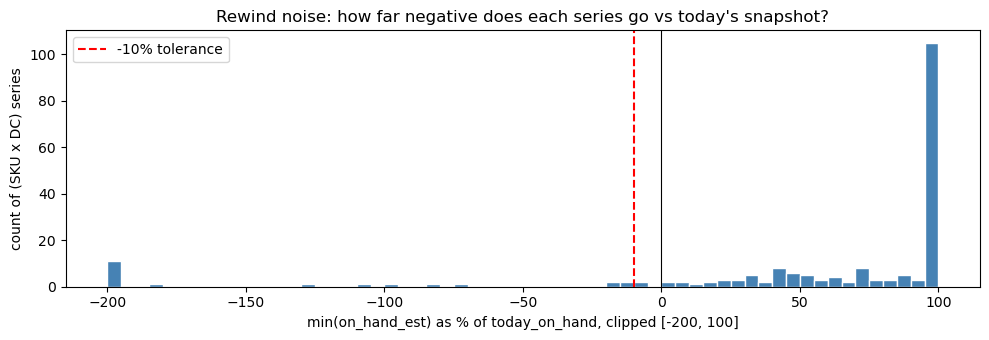

T-32206 SF [high]: today=  264417  min=  -17450  max=  370678
T-32206 NJ [high]: today=  364715  min=  117196  max=  842086
T-32206 LA [high]: today=  144207  min=   90529  max=  410328


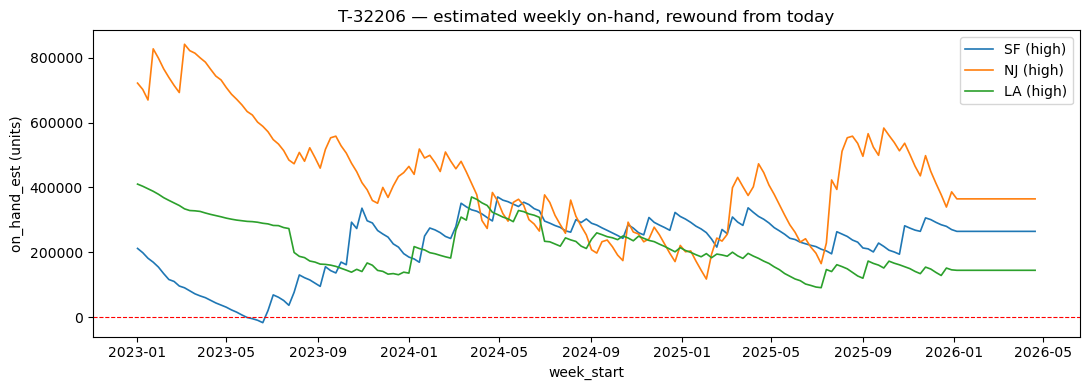


duplicate (ITEMNMBR, DC, week_start): 0
null on_hand_est: 865


In [5]:
# ---- Check 1: today's rewind should equal today's snapshot (identity) -------
today_week = weeks.max()
today_rewind = inv_weekly[inv_weekly['week_start'] == today_week].copy()
check = today_rewind.merge(
    sku_dc.rename(columns={'SKU': 'ITEMNMBR'}),
    on=['ITEMNMBR', 'DC'], how='left'
)
diff = (check['on_hand_est'] - check['today_on_hand']).abs()
print(f'today_rewind vs snapshot: max |diff| = {diff.max():.3f}  mean = {diff.mean():.3f}')
assert diff.max() < 1e-6, 'Rewind broken: today\'s estimate != snapshot'
print('identity check: PASS')

# ---- Check 2: how noisy is the rewind? --------------------------------------
print('\nmin_on_hand_est distribution (across all SKU x DC series):')
print(conf['min_est'].describe().to_string())

print('\nshare of series by severity of data gap (vs tolerance):')
conf['gap'] = -conf['min_est'] / conf['tolerance'].replace(0, np.nan)
print(f"  clean (min >= 0)               : {(conf['min_est'] >= 0).mean()*100:5.1f}%")
print(f"  minor (0 > min >= -tolerance)  : {((conf['min_est'] < 0) & (conf['confidence']=='high')).mean()*100:5.1f}%")
print(f"  low-confidence (min < -tol)    : {(conf['confidence']=='low').mean()*100:5.1f}%")

# Plot: histogram of min_est as % of today_on_hand (where today>0)
mask = conf['today_on_hand'] > 0
rel = (conf.loc[mask, 'min_est'] / conf.loc[mask, 'today_on_hand']) * 100
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.hist(rel.clip(-200, 100), bins=60, color='steelblue', edgecolor='white')
ax.axvline(0, color='black', linestyle='-', lw=0.8)
ax.axvline(-10, color='red', linestyle='--', label='-10% tolerance')
ax.set_xlabel('min(on_hand_est) as % of today_on_hand, clipped [-200, 100]')
ax.set_ylabel('count of (SKU x DC) series')
ax.set_title('Rewind noise: how far negative does each series go vs today\'s snapshot?')
ax.legend()
plt.tight_layout()
plt.show()

# ---- Check 3: spot-check one showcase SKU (T-32206, Tiger Balm Patch) -------
sku = 'T-32206'
for dc in ['SF', 'NJ', 'LA']:
    s = inv_weekly[(inv_weekly['ITEMNMBR'] == sku) & (inv_weekly['DC'] == dc)]
    if len(s) == 0:
        print(f'{sku} {dc}: (not in snapshot)')
        continue
    conf_val = s['confidence'].iloc[0]
    print(f'{sku} {dc} [{conf_val:>4}]: today={s["on_hand_est"].iloc[-1]:8.0f}  '
          f'min={s["on_hand_est"].min():8.0f}  max={s["on_hand_est"].max():8.0f}')

# Plot the spot-check SKU across all 3 DCs
fig, ax = plt.subplots(figsize=(11, 4))
for dc in ['SF', 'NJ', 'LA']:
    s = inv_weekly[(inv_weekly['ITEMNMBR'] == sku) & (inv_weekly['DC'] == dc)]
    if len(s):
        conf_val = s['confidence'].iloc[0]
        ax.plot(s['week_start'], s['on_hand_est'], label=f'{dc} ({conf_val})', lw=1.2)
ax.axhline(0, color='red', lw=0.8, linestyle='--')
ax.set_title(f'{sku} — estimated weekly on-hand, rewound from today')
ax.set_xlabel('week_start')
ax.set_ylabel('on_hand_est (units)')
ax.legend()
plt.tight_layout()
plt.show()

# ---- Check 4: dup + null sanity --------------------------------------------
dups = inv_weekly.duplicated(subset=['ITEMNMBR', 'DC', 'week_start']).sum()
nulls = inv_weekly['on_hand_est'].isna().sum()
print(f'\nduplicate (ITEMNMBR, DC, week_start): {dups}')
print(f'null on_hand_est: {nulls}')

## 5. Save downstream artifact

In [6]:
inv_weekly.to_parquet(ART / 'inv_weekly.parquet')
print(f'inv_weekly  {inv_weekly.shape}  -> inv_weekly.parquet')

# Anchor + tolerance settings for downstream reference. All values stringified
# so parquet's strict column typing is happy (was mixing str dates + float nums).
meta = pd.DataFrame({
    'key':   ['anchor_today', 'rewind_start', 'tolerance_pct', 'tolerance_floor'],
    'value': [str(today.date()), str(weeks.min().date()), '0.10', '50'],
})
meta.to_parquet(ART / 'inv_rewind_meta.parquet')
print(f'meta        {meta.shape}  -> inv_rewind_meta.parquet')

inv_weekly  (37887, 5)  -> inv_weekly.parquet
meta        (4, 2)  -> inv_rewind_meta.parquet


## 6. Promote

Done — logic lives in `src/inventory.py`. Public API: `build_inv_weekly(sales, po, transfers, inv_snap, dc_map, tolerance_floor, tolerance_pct) -> (inv_weekly, meta)` plus helpers `learn_uom_pack`, `normalize_sales_to_base`, `normalize_transfers_to_base`, `weekly_sum`. Downstream steps should import from there.
